#### Imports and Project set up

In [2]:
from pathlib import Path
import sys

# Project root = parent of the notebooks directory
PROJECT_ROOT = Path.cwd().parent

# Make the project root importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.dataset import get_dataset_paths
from src.data.annotations import load_annotations

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\smrut\Documents\Projects\AirCommand


#### 1. Load the Annotations

In [3]:
paths = get_dataset_paths()

train_annotations = load_annotations(paths.train_annotations)
test_annotations = load_annotations(paths.test_annotations)
all_annotations = load_annotations(paths.annotations)

print("Train:", train_annotations.shape)
print("Test:", test_annotations.shape)
print("All:", all_annotations.shape)

Train: (4039, 6)
Test: (1610, 6)
All: (5650, 6)


#### Annotations table and information

In [4]:
all_annotations.head()

,video,label,class_id,start_frame,end_frame,frame_count
0,video,label,id,t_start,t_end,frames
1,1CM1_4_R__229,D0X,1,1,17,17
2,1CM1_4_R__229,G11,14,18,55,38
3,1CM1_4_R__229,B0B,3,56,284,229
4,1CM1_4_R__229,G04,7,285,308,24


In [5]:
all_annotations.info()

<class 'pandas.DataFrame'>
RangeIndex: 5650 entries, 0 to 5649
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   video        5650 non-null   str  
 1   label        5650 non-null   str  
 2   class_id     5650 non-null   str  
 3   start_frame  5650 non-null   str  
 4   end_frame    5650 non-null   str  
 5   frame_count  5650 non-null   str  
dtypes: str(6)
memory usage: 265.0 KB


In [6]:
all_annotations["label"].value_counts()

label
D0X      1431
B0A      1010
B0B      1007
G04       201
G11       200
G05       200
G03       200
G02       200
G08       200
G06       200
G10       200
G09       200
G07       200
G01       200
label       1
Name: count, dtype: int64

#### 1.1 Decode the class labels

In [8]:
class_details = pd.read_csv(
    paths.class_details,
    sep='\t',
    skipinitialspace=True
)

class_details.columns.to_list()

['id', 'Label', 'Gesture', 'Instances', 'Unnamed: 4', 'Unnamed: 5']

In [13]:
all_annotations = all_annotations[
    all_annotations["label"].isin(
        class_details["Label"]
    )
].copy()

print("Shape after removing invalid rows:", all_annotations.shape)

print("\nNumber of classes:")
print(all_annotations["label"].nunique())

print("\nClass counts:")
print(all_annotations["label"].value_counts())

Shape after removing invalid rows: (5649, 6)

Number of classes:
14

Class counts:
label
D0X    1431
B0A    1010
B0B    1007
G04     201
G11     200
G05     200
G03     200
G02     200
G08     200
G06     200
G10     200
G09     200
G07     200
G01     200
Name: count, dtype: int64


#### 1.2 Distribution of class by train/test

In [14]:
train_counts = train_annotations["label"].value_counts()
test_counts = test_annotations["label"].value_counts()

distribution = pd.DataFrame({
    "train": train_counts,
    "test": test_counts,
}).fillna(0).astype(int)

distribution

,train,test
label,,
B0A,745,265
B0B,743,264
D0X,922,509
G01,148,52
G02,148,52
G03,148,52
G04,149,52
G05,148,52
G06,148,52


#### 1.3 Length of annotated sequences

In [17]:
all_annotations["frame_count"] = pd.to_numeric(
    all_annotations["frame_count"],
    errors="coerce",
)

sequence_lengths = all_annotations["frame_count"]

print(sequence_lengths.describe())

print("\nShortest sequence:", sequence_lengths.min())
print("Median sequence:", sequence_lengths.median())
print("Longest sequence:", sequence_lengths.max())

count    5649.000000
mean      141.704904
std       105.264143
min         7.000000
25%        53.000000
50%       105.000000
75%       217.000000
max       970.000000
Name: frame_count, dtype: float64

Shortest sequence: 7
Median sequence: 105.0
Longest sequence: 970


#### 1.4 Distribution of sequence length by class

In [18]:
class_length_summary = (
    all_annotations
    .groupby("label")["frame_count"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .sort_values("median")
    .round(2)
)

class_length_summary

,count,mean,median,min,max
label,,,,,
G01,200,55.98,48.0,13,167
G02,200,59.68,49.0,18,525
G03,200,62.00,56.0,15,139
G06,200,63.80,57.0,22,174
G11,200,64.32,58.0,19,181
G10,200,65.17,59.0,18,184
G04,201,65.15,59.0,13,181
G05,200,66.13,60.0,21,165
G08,200,67.62,60.5,27,205


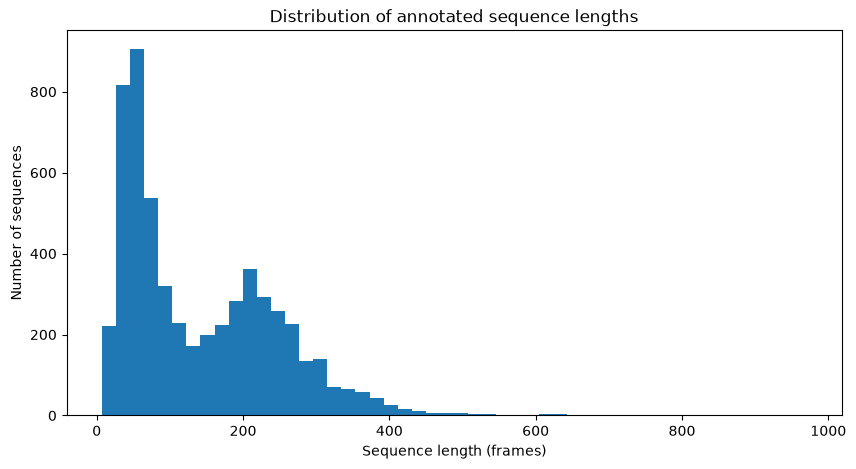

In [ ]:
## Visualization: Histogram is right skewed: mean>median

plt.figure(figsize=(10, 5))

plt.hist(
    all_annotations["frame_count"],
    bins=50,
)

plt.xlabel("Sequence length (frames)")
plt.ylabel("Number of sequences")
plt.title("Distribution of annotated sequence lengths")

plt.show()

#### 1.4 Dataset coverage for a specific sequence length

In [20]:
candidate_lengths = [64, 96, 128, 160, 192, 256, 320, 384, 512]

coverage = []

for length in candidate_lengths:
    percentage = (
        all_annotations["frame_count"] <= length
    ).mean() * 100

    coverage.append({
        "sequence_length": length,
        "coverage_percent": percentage,
    })

coverage_df = pd.DataFrame(coverage)

coverage_df

,sequence_length,coverage_percent
0,64,34.395468
1,96,47.689857
2,128,54.505222
3,160,60.010621
4,192,67.268543
5,256,85.006196
6,320,94.494601
7,384,97.964241
8,512,99.592848


#### 1.5 Coverage excluding D0X

In [21]:
gesture_annotations = all_annotations[
    all_annotations["label"] != "D0X"
].copy()

gesture_coverage = []

for length in candidate_lengths:
    percentage = (
        gesture_annotations["frame_count"] <= length
    ).mean() * 100

    gesture_coverage.append({
        "sequence_length": length,
        "coverage_percent": percentage,
    })

gesture_coverage_df = pd.DataFrame(
    gesture_coverage
)

gesture_coverage_df

,sequence_length,coverage_percent
0,64,31.839734
1,96,45.993362
2,128,53.295401
3,160,59.483167
4,192,67.757231
5,256,87.174016
6,320,96.538644
7,384,99.027975
8,512,99.905168


#### 2. Metadata EDA

In [22]:
metadata = pd.read_excel(paths.metadata)

print("Shape:", metadata.shape)
print("\nColumns:")
print(metadata.columns.tolist())

metadata.head()

Shape: (200, 9)

Columns:
['Video Name', 'Frames', 'Sex', 'Hand', 'Background', 'Illumination', 'People in Scene', 'Background Motion', 'Set']


,Video Name,Frames,Sex,Hand,Background,Illumination,People in Scene,Background Motion,Set
0,1CM1_4_R__229,3751,W,Right,Clutter,Stable,Single,Static,train
1,1CM1_4_R__230,3684,W,Right,Clutter,Stable,Single,Static,train
2,1CM1_4_R__231,3747,W,Right,Clutter,Stable,Single,Static,train
3,1CM1_4_R__232,3858,W,Right,Clutter,Stable,Single,Static,train
4,1CM42_11_R__205,3686,M,Right,Plain,Stable,Single,Static,train


In [23]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Video Name         200 non-null    str  
 1   Frames             200 non-null    int64
 2   Sex                200 non-null    str  
 3   Hand               200 non-null    str  
 4   Background         200 non-null    str  
 5   Illumination       200 non-null    str  
 6   People in Scene    200 non-null    str  
 7   Background Motion  200 non-null    str  
 8   Set                200 non-null    str  
dtypes: int64(1), str(8)
memory usage: 14.2 KB


#### 2.1 Diversity of recording conditions

In [24]:
environment_columns = [
    "Background",
    "Illumination",
    "People in Scene",
    "Background Motion",
]

for column in environment_columns:
    print(f"\n{column}")
    print(metadata[column].value_counts())


Background
Background
Clutter     103
Plain        94
Clutter       3
Name: count, dtype: int64

Illumination
Illumination
Stable    131
Light      57
Dark       12
Name: count, dtype: int64

People in Scene
People in Scene
Single    171
Multi      29
Name: count, dtype: int64

Background Motion
Background Motion
Static     153
Dynamic     47
Name: count, dtype: int64


#### 2.2 Fix the "Clutter " formatting

In [26]:
metadata["Background"] = metadata["Background"].str.strip()
print(metadata["Background"].value_counts())

Background
Clutter    106
Plain       94
Name: count, dtype: int64


## Key Findings
1. One Annotation row represents one annotated temporal segment of a video
2. There are 14 classes, D0X is the most frequently appearing class. The gesture classes are imbalanced.
3. The same three-group pattern appears in both train and test, so the imbalance isn't an accident of one split.
4. Sequence lengths vary from 7 (shortest) to 970 (longest)

## Metadata EDA Findings
1. Backgroud may be cluttered or plain (stable variance)
2. Illumination is strongly concentrated in stable lighting
3. Strongly includes single-person scenes
4. Videos are mostly static

#### 3. Gesture Sequences

#### 3.1 Basic Statistics

In [27]:
all_annotations["frame_count"].describe()

count    5649.000000
mean      141.704904
std       105.264143
min         7.000000
25%        53.000000
50%       105.000000
75%       217.000000
max       970.000000
Name: frame_count, dtype: float64

In [28]:
percentiles = all_annotations["frame_count"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

percentiles

0.50    105.0
0.75    217.0
0.90    281.0
0.95    328.0
0.99    426.0
Name: frame_count, dtype: float64

#### 3.2 Coverage at different fixed lengths

In [32]:
lengths = [64, 96, 128, 160, 192, 256, 320, 384, 512]

coverage = {}

for length in lengths:
    coverage[length] = (
        all_annotations["frame_count"] <= length
    ).mean() * 100

coverage

{64: np.float64(34.39546822446451),
 96: np.float64(47.6898566117897),
 128: np.float64(54.505222163214725),
 160: np.float64(60.01062134891131),
 192: np.float64(67.26854310497433),
 256: np.float64(85.00619578686494),
 320: np.float64(94.49460081430342),
 384: np.float64(97.96424145866524),
 512: np.float64(99.59284829173305)}

#### 3.3 Effect on removing D0X non gesture class

In [30]:
gesture_annotations = all_annotations[
    all_annotations["label"] != "D0X"
].copy()

gesture_annotations["frame_count"].describe()

count    4218.000000
mean      139.864628
std        93.965715
min         9.000000
25%        57.000000
50%       112.000000
75%       213.000000
max       650.000000
Name: frame_count, dtype: float64

In [33]:
lengths = [64, 96, 128, 160, 192, 256, 320, 384, 512]

gcoverage = {}

for length in lengths:
    gcoverage[length] = (
        gesture_annotations["frame_count"] <= length
    ).mean() * 100

gcoverage

{64: np.float64(31.83973447131342),
 96: np.float64(45.99336178283547),
 128: np.float64(53.29540066382171),
 160: np.float64(59.48316737790422),
 192: np.float64(67.75723091512566),
 256: np.float64(87.17401612138454),
 320: np.float64(96.53864390706495),
 384: np.float64(99.02797534376482),
 512: np.float64(99.90516832622096)}

#### 3.4 Length by class

In [34]:
class_length_stats = (
    gesture_annotations
    .groupby("label")["frame_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

class_length_stats

,count,mean,median,min,max
label,,,,,
B0B,1007,224.114201,217.0,10,650
B0A,1010,219.002970,214.0,9,624
G07,200,75.630000,66.0,23,163
G09,200,69.550000,62.0,25,238
G08,200,67.625000,60.5,27,205
G05,200,66.130000,60.0,21,165
G10,200,65.165000,59.0,18,184
G04,201,65.149254,59.0,13,181
G11,200,64.325000,58.0,19,181


<Figure size 1200x600 with 0 Axes>

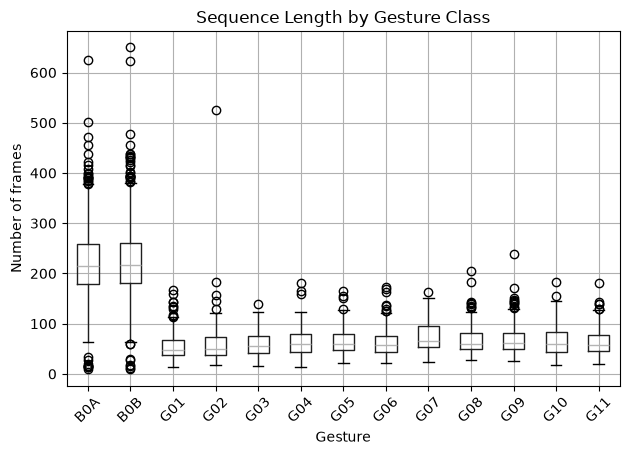

In [35]:
plt.figure(figsize=(12, 6))

gesture_annotations.boxplot(
    column="frame_count",
    by="label",
    rot=45,
)

plt.title("Sequence Length by Gesture Class")
plt.suptitle("")
plt.xlabel("Gesture")
plt.ylabel("Number of frames")
plt.tight_layout()
plt.show()

In [36]:
class_counts = gesture_annotations["label"].value_counts().sort_index()

class_counts

label
B0A    1010
B0B    1007
G01     200
G02     200
G03     200
G04     201
G05     200
G06     200
G07     200
G08     200
G09     200
G10     200
G11     200
Name: count, dtype: int64

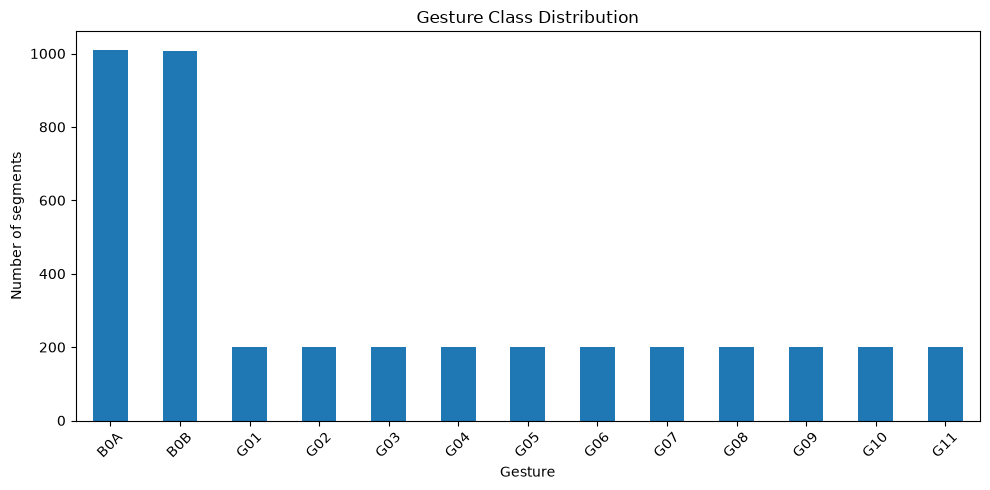

In [37]:
class_counts.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Gesture Class Distribution")
plt.xlabel("Gesture")
plt.ylabel("Number of segments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.5 Train vs test class distribution

In [ ]:
## counts
train_gesture = train_annotations[
    train_annotations["label"] != "D0X"
]

test_gesture = test_annotations[
    test_annotations["label"] != "D0X"
]

train_counts = train_gesture["label"].value_counts().sort_index()
test_counts = test_gesture["label"].value_counts().sort_index()

comparison = pd.DataFrame({
    "train": train_counts,
    "test": test_counts,
})

comparison

,train,test
label,,
B0A,745,265
B0B,743,264
G01,148,52
G02,148,52
G03,148,52
G04,149,52
G05,148,52
G06,148,52
G07,148,52


In [39]:
## sequence length
length_comparison = pd.DataFrame({
    "train": train_gesture["frame_count"].describe(),
    "test": test_gesture["frame_count"].describe(),
})

length_comparison

,train,test
count,3117.000000,1101.000000
mean,139.379211,141.238874
std,93.264366,95.953114
min,9.000000,10.000000
25%,57.000000,56.000000
50%,113.000000,110.000000
75%,212.000000,216.000000
max,624.000000,650.000000


In [ ]:
paths = get_dataset_paths()

train_annotations = load_annotations(paths.train_annotations)
test_annotations = load_annotations(paths.test_annotations)
all_annotations = load_annotations(paths.annotations)

print("Train:", train_annotations.shape)
print("Test:", test_annotations.shape)
print("All:", all_annotations.shape)

Train: (4039, 6)
Test: (1610, 6)
All: (5650, 6)


## Gesture Sequences key findings
1. The sequence-length distribution is right-skewed. The median sequence contains 105 frames, while the mean is higher at about 141 frames because a smaller number of much longer sequences pull the mean upward.
2. D0X contributes some of the very long sequences, so removing it reduces the extreme tail. (970 -> 650)
3. Sequence length is not uniformly distributed across gesture classes.

## Overall EDA Conclusions
1. Annotation structure

5,649 annotated segments after removing the accidental header row.
14 classes in the dataset: 1 non-gesture + 13 gestures.
Train/test annotations follow the expected structure.

2. Class distribution

D0X has the most segments among all classes.
Among the 13 gesture classes, B0A and B0B have ~1,000 each.
G01-G11 have ~200 each.
Train and test show a similar class pattern.

3. Sequence length

Overall distribution is right-skewed.
Mean ≈ 141 frames, median ≈ 105.
Gesture-only maximum drops from 970 to 650 frames.
Sequence length varies substantially by gesture.
B0A/B0B are generally much longer than G01-G11.
A small number of unusually long sequences form the tail.

4. Recording conditions

Background: roughly balanced between cluttered and plain.
Illumination: mostly stable, relatively few dark videos.
People: mostly single-person scenes.
Background motion: mostly static.
These factors could potentially influence landmark detection, but we've not established that they actually do yet.

5. Train/test consistency

Class distributions are similar.
Sequence-length statistics are also similar.
That's useful because we don't see an obvious train/test distribution mismatch at this level.